In [1]:
import sys
# !{sys.executable} -m pip install langchain-text-splitters langgraph

In [2]:
import os
os.environ['USER_AGENT'] = 'Mozilla/5.0 (Windows NT 6.1; Win64; x64; rv:47.0) Gecko/20100101 Firefox/47.0'
import langchain
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_core.vectorstores import InMemoryVectorStore
import bs4
from langchain import hub
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
langchain.__version__


'0.3.27'

In [3]:
with open("data/secrets/key.secret") as f:
    os.environ["OPENAI_API_KEY"] = f.read()

In [4]:
url = "https://en.wikipedia.org/wiki/Retrieval-augmented_generation"

loader = WebBaseLoader(
    web_paths=(url,),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("mw-body-content",)
        )
    ),
)
docs = loader.load()
docs

[Document(metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content='Type of information retrieval using LLMs\nRetrieval-augmented generation (RAG) is a technique that enables large language models (LLMs) to retrieve and incorporate new information.[1] With RAG, LLMs do not respond to user queries until they refer to a specified set of documents. These documents supplement information from the LLM\'s pre-existing training data.[2] This allows LLMs to use domain-specific and/or updated information that is not available in the training data.[2] For example, this helps LLM-based chatbots access internal company data or generate responses based on authoritative sources.\nRAG improves large language models (LLMs) by incorporating information retrieval before generating responses.[3] Unlike traditional LLMs that rely on static training data, RAG pulls relevant text from databases, uploaded documents, or web sources.[1] According to Ars Technica, "RAG i

In [5]:
text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)
all_splits

[Document(metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content="Type of information retrieval using LLMs\nRetrieval-augmented generation (RAG) is a technique that enables large language models (LLMs) to retrieve and incorporate new information.[1] With RAG, LLMs do not respond to user queries until they refer to a specified set of documents. These documents supplement information from the LLM's pre-existing training data.[2] This allows LLMs to use domain-specific and/or updated information that is not available in the training data.[2] For example, this helps LLM-based chatbots access internal company data or generate responses based on authoritative sources."),
 Document(metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content='RAG improves large language models (LLMs) by incorporating information retrieval before generating responses.[3] Unlike traditional LLMs that rely on static training data, RA

In [6]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-large")
vector_store = InMemoryVectorStore(embeddings)
db = vector_store.add_documents(documents=all_splits)
db

['967594b8-5c40-408f-9ea3-075d8b9a0032',
 '087f92cd-8668-4ab8-a4ab-f68cb9f6b784',
 '8e2dbde3-803c-4172-b085-9f902d8ce6b3',
 '17085b9f-5156-431c-8d4f-0cdc1494f925',
 'a415850f-78eb-435f-8a32-3bb38a6e50d4',
 'c9df9d23-01a6-4298-8061-2cacc6c9ace2',
 '1feb54a1-22f3-468b-88f5-8e833b7d05a5',
 '6baa532b-bf81-4c7e-811e-73e96f5df7ed',
 'a7754104-d014-490d-bf0e-1c814e9caee5',
 '8b771e1b-9ae5-42eb-9ff7-a9dd313e7b15',
 '9ab046dc-d708-4aee-880c-8f09805ad6bf',
 '06417dc2-6035-496e-98a4-2f0e088cb812',
 'f642e0a7-254c-4959-bf94-a1c7567212a0',
 'e5ea7bc0-d02c-4f87-a152-201c7e3f0a9b',
 'c2d8eb4d-cbe1-4bdb-b1c8-4b381771c00d',
 '66710444-9707-401e-9bc6-3ec06e465ca8',
 '55ad1909-fd49-4f4c-9d3f-9671e5362d9f',
 '6ede83f0-a9eb-4ec2-8a7a-94afad208403',
 '94b028a4-ebda-47d7-9ddd-791cbdf48df3',
 'c2f92378-e978-4d62-ad51-1893e64fdcf5',
 '3c9a5da1-47a7-4d48-8b1b-3f4e4cd608cf',
 '63e53242-173f-4820-bab8-bdbe4690dbc6',
 'a26a280b-3269-40ba-9f18-290bef88e874',
 '00988bfd-9635-4e48-8a86-a7d5c30bac29',
 '1992b8f0-119c-

In [17]:
template="""
You are an assistant for question-answering tasks.
Use the following pieces of retrieved context to answer the question.
If you don't know the answer, just say that you don't know.
Use {nb} sentences maximum and keep the answer concise.
Question: {question}
Context: {context}
Answer:
"""
prompt = ChatPromptTemplate.from_messages(
    [("user", template)]
)
prompt

ChatPromptTemplate(input_variables=['context', 'nb', 'question'], input_types={}, partial_variables={}, messages=[HumanMessagePromptTemplate(prompt=PromptTemplate(input_variables=['context', 'nb', 'question'], input_types={}, partial_variables={}, template="\nYou are an assistant for question-answering tasks.\nUse the following pieces of retrieved context to answer the question.\nIf you don't know the answer, just say that you don't know.\nUse {nb} sentences maximum and keep the answer concise.\nQuestion: {question}\nContext: {context}\nAnswer:\n"), additional_kwargs={})])

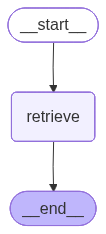

In [18]:
llm = init_chat_model("gpt-4o-mini", model_provider="openai")

class State(TypedDict):
    question: str
    context: List[Document]
    answer: str


# Define application steps
def retrieve(state: State):
    retrieved_docs = vector_store.similarity_search(state["question"])
    return {"context": retrieved_docs}

# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()
graph

In [19]:
response = graph.invoke({"question": "Qu'est ce que le RAG?"})
response

{'question': "Qu'est ce que le RAG?",
 'context': [Document(id='8e2dbde3-803c-4172-b085-9f902d8ce6b3', metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content='RAG also reduces the need to retrain LLMs with new data, saving on computational and financial costs.[1] Beyond efficiency gains, RAG also allows LLMs to include sources in their responses, so users can verify the cited sources. This provides greater transparency, as users can cross-check retrieved content to ensure accuracy and relevance.\nThe term RAG was first introduced in a 2020 research paper.[3]'),
  Document(id='1feb54a1-22f3-468b-88f5-8e833b7d05a5', metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content='RAG key stages[edit]\nOverview of RAG process, combining external documents and user input into an LLM prompt to get tailored output\nTypically, the data to be referenced is converted into LLM embeddings, numerical representations in th

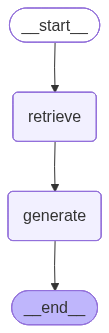

In [20]:
def generate(state: State):
    docs_content = "\n\n".join(doc.page_content for doc in state["context"])
    messages = prompt.invoke({"question": state["question"], "context": docs_content, "nb":3})
    response = llm.invoke(messages)
    return {"answer": response.content}


# Compile application and test
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()
graph

In [21]:
response = graph.invoke({"question": "Qu'est ce que le RAG?"})
response

{'question': "Qu'est ce que le RAG?",
 'context': [Document(id='8e2dbde3-803c-4172-b085-9f902d8ce6b3', metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content='RAG also reduces the need to retrain LLMs with new data, saving on computational and financial costs.[1] Beyond efficiency gains, RAG also allows LLMs to include sources in their responses, so users can verify the cited sources. This provides greater transparency, as users can cross-check retrieved content to ensure accuracy and relevance.\nThe term RAG was first introduced in a 2020 research paper.[3]'),
  Document(id='1feb54a1-22f3-468b-88f5-8e833b7d05a5', metadata={'source': 'https://en.wikipedia.org/wiki/Retrieval-augmented_generation'}, page_content='RAG key stages[edit]\nOverview of RAG process, combining external documents and user input into an LLM prompt to get tailored output\nTypically, the data to be referenced is converted into LLM embeddings, numerical representations in th

In [22]:
response["answer"]

'Le RAG, ou "Retrieval-Augmented Generation," est une technique qui améliore les modèles de langage (LLMs) en leur permettant de récupérer et d\'incorporer de nouvelles informations avant de générer des réponses. Contrairement aux LLMs traditionnels, RAG utilise des documents externes pour compléter les données d\'entraînement préexistantes, ce qui réduit les hallucinations et permet une plus grande précision. Cette méthode augmente l\'efficacité tout en offrant aux utilisateurs la possibilité de vérifier les sources des informations fournies.'

In [ ]:
#TODO voir le detail
#TODO avec d'autres loader
#TODO telecharger les documents en local